### Introducción a SVM

Support Vector Machines (SVM) son un conjunto de métodos supervisados utilizados tanto para clasificación como para regresión. SVM tiene varias ventajas, entre ellas su efectividad en espacios de alta dimensionalidad y su uso eficiente de la memoria.

### 1. Instalación de Bibliotecas Necesarias

Primero, asegúrate de tener instaladas las bibliotecas necesarias. Si no las tienes, puedes instalarlas usando pip:

```sh
pip install numpy matplotlib scikit-learn
```

### 2. Importar Bibliotecas

Comencemos importando las bibliotecas necesarias:


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


### 3. Datos Artificiales para Clasificación

Primero, crearemos algunos datos artificiales para clasificación. Usaremos la función `make_blobs` de `scikit-learn`.


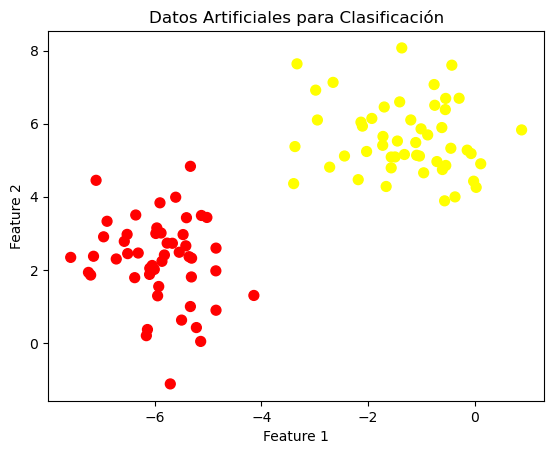

In [3]:
from sklearn.datasets import make_blobs

# Crear datos artificiales
X, y = make_blobs(n_samples=100, centers=2, random_state=1234)

# Visualizar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Datos Artificiales para Clasificación')
plt.show()


### 4. Clasificación con SVM (Kernel Lineal)

Primero, probaremos el kernel lineal.


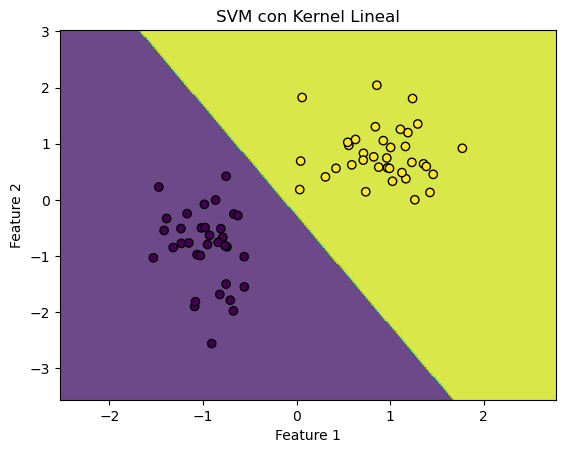

In [4]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estándarizar características
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crear el modelo SVM con kernel lineal
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# Predicción
y_pred = svm_linear.predict(X_test)

# Visualización del límite de decisión
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('SVM con Kernel Lineal')
    plt.show()

plot_decision_boundary(X_train,y_train, svm_linear)



### 5. Clasificación con SVM (Kernel Polinómico)

Ahora probaremos con un kernel polinómico.

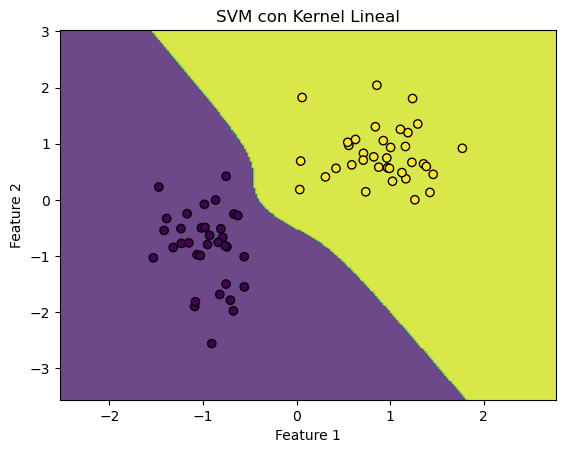

In [5]:
# Crear el modelo SVM con kernel polinómico
svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train, y_train)

# Predicción
y_pred_poly = svm_poly.predict(X_test)

# Visualización del límite de decisión
plot_decision_boundary(X_train,y_train, svm_poly)


### 6. Clasificación con SVM (Kernel Gaussiano/RBF)

Por último, usaremos un kernel gaussiano (RBF).


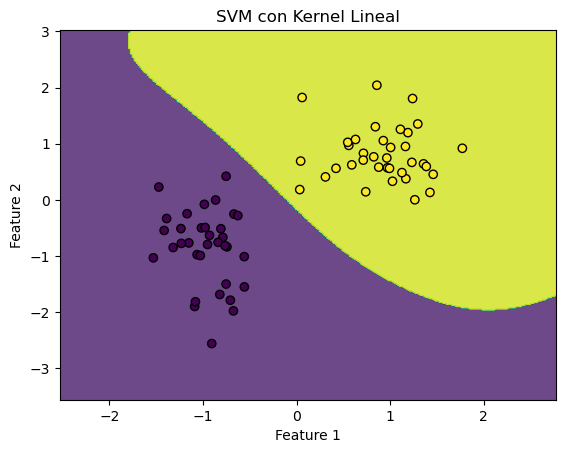

In [6]:
# Crear el modelo SVM con kernel gaussiano
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

# Predicción
y_pred_rbf = svm_rbf.predict(X_test)

# Visualización del límite de decisión
plot_decision_boundary(X_train, y_train, svm_rbf)


### 7. Datos Artificiales para Regresión

Ahora crearemos algunos datos artificiales para regresión.


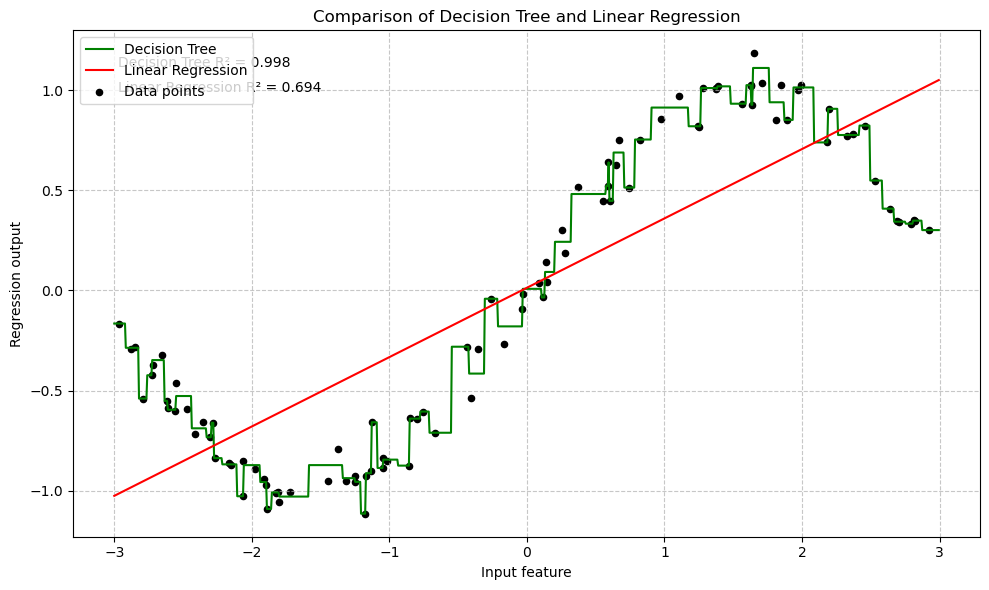

Decision Tree R² Score: 0.998
Linear Regression R² Score: 0.694


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Create a custom wave-like dataset
np.random.seed(42)
n_samples = 100
X = np.sort(np.random.rand(n_samples) * 6 - 3)
y = np.sin(X) + np.random.normal(0, 0.1, n_samples)
X = X.reshape(-1, 1)

# Create line for predictions
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

# Fit Decision Tree Regressor
dt_reg = DecisionTreeRegressor(min_samples_split=3).fit(X, y)
dt_predictions = dt_reg.predict(line)

# Fit Linear Regression
lin_reg = LinearRegression().fit(X, y)
lin_predictions = lin_reg.predict(line)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(line, dt_predictions, label="Decision Tree", color='g')
plt.plot(line, lin_predictions, label="Linear Regression", color='r')
plt.scatter(X, y, c='k', s=20, label="Data points")
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.title("Comparison of Decision Tree and Linear Regression")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)

# Add text annotations for model scores
dt_score = dt_reg.score(X, y)
lin_score = lin_reg.score(X, y)
plt.text(0.05, 0.95, f'Decision Tree R² = {dt_score:.3f}', transform=plt.gca().transAxes, verticalalignment='top')
plt.text(0.05, 0.90, f'Linear Regression R² = {lin_score:.3f}', transform=plt.gca().transAxes, verticalalignment='top')

plt.tight_layout()
plt.show()

# Print model scores
print(f"Decision Tree R² Score: {dt_score:.3f}")
print(f"Linear Regression R² Score: {lin_score:.3f}")

### 8. Regresión con SVM (Kernel Lineal)

Primero probaremos el kernel lineal para regresión.


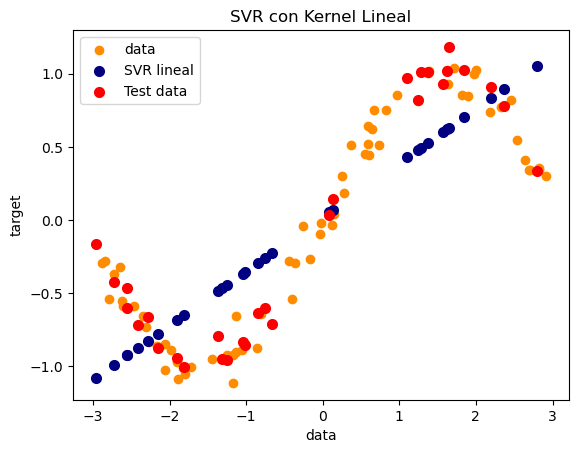

In [12]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear el modelo SVR con kernel lineal
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)

# Predicción
y_pred = svr_linear.predict(X_test)

# Visualización de ajuste
plt.scatter(X_train, y_train, color='darkorange', label='data')
plt.scatter(X_test, y_pred, color='navy', lw=2, label='SVR lineal')
plt.scatter(X_test, y_test, color='red', lw=2, label='Test data')
plt.xlabel('data')
plt.ylabel('target')
plt.title('SVR con Kernel Lineal')
plt.legend()
plt.show()

### 9. Regresión con SVM (Kernel Polinómico)

Ahora probaremos con un kernel polinómico.

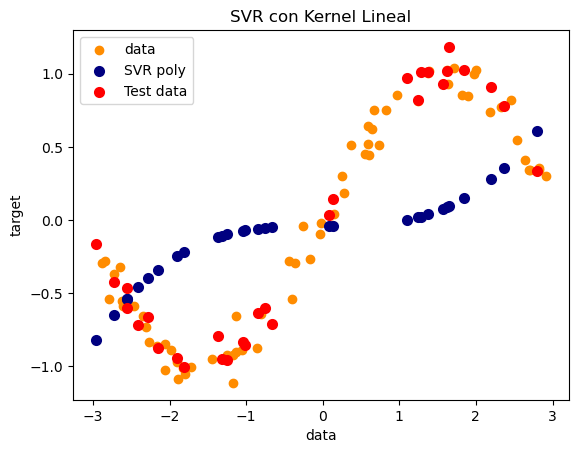

In [18]:
# Crear el modelo SVR con kernel polinómico
svr_poly = SVR(kernel='poly', degree=3)
svr_poly.fit(X_train, y_train)

# Predicción
y_pred_poly = svr_poly.predict(X_test)


# Visualización de ajuste
plt.scatter(X_train, y_train, color='darkorange', label='data')
plt.scatter(X_test, y_pred_poly, color='navy', lw=2, label='SVR poly')
plt.scatter(X_test, y_test, color='red', lw=2, label='Test data')
plt.xlabel('data')
plt.ylabel('target')
plt.title('SVR con Kernel Lineal')
plt.legend()
plt.show()

### 10. Regresión con SVM (Kernel Gaussiano/RBF)

Por último, usaremos un kernel gaussiano (RBF).


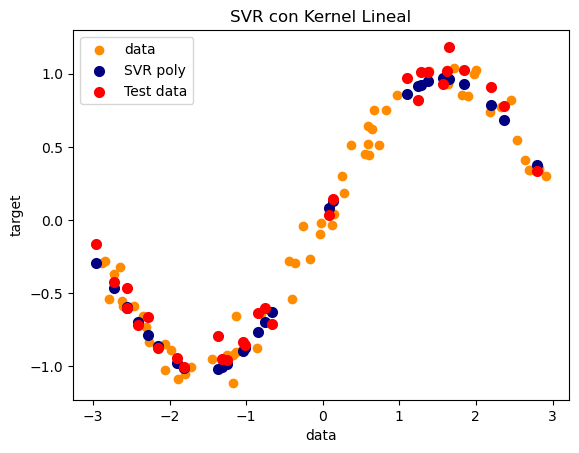

In [14]:
# Crear el modelo SVR con kernel gaussiano
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)

# Predicción
y_pred_rbf = svr_rbf.predict(X_test)

# Visualización de ajuste
plt.scatter(X_train, y_train, color='darkorange', label='data')
plt.scatter(X_test, y_pred_rbf, color='navy', lw=2, label='SVR poly')
plt.scatter(X_test, y_test, color='red', lw=2, label='Test data')
plt.xlabel('data')
plt.ylabel('target')
plt.title('SVR con Kernel Lineal')
plt.legend()
plt.show()

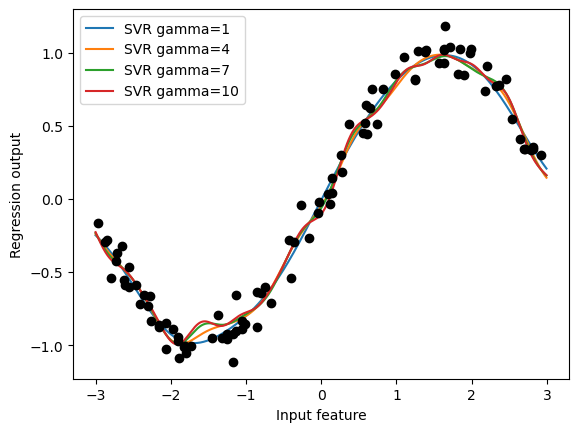

In [15]:
from sklearn.svm import SVR

for gamma in range(1,11,3):
    svr = SVR(gamma=gamma).fit(X, y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma))
    
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")